# 01 - Data audit and EDA

Run this **before** trusting any result: it verifies the assumptions behind the cleaning rules on the real file.
Set `DATA` to the real CSV (default) or to a synthetic file for a dry run.

In [2]:
import sys, json, os
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from lte_forecast.config import DataCfg
from lte_forecast.data import load_panel

DATA = os.environ.get('LTE_DATA', str(ROOT / 'data' / 'Dataset_02_LTE_1800.csv'))
panel, audit = load_panel(DataCfg(path=DATA))
print(json.dumps(audit, indent=2, default=str))

{
  "raw": {
    "n_rows": 1800920,
    "n_sites": 63,
    "n_cells": 184,
    "ts_min": "2025-02-07 19:45:00",
    "ts_max": "2025-05-05 07:15:00",
    "n_off_grid_timestamps": 0,
    "n_exact_duplicate_rows": 0,
    "n_duplicate_keys_after_exact_dedup": 1078375,
    "missing_share_by_column": {
      "energy_ru": 0.0471,
      "energy_bb": 0.0471,
      "max_users_dl": 0.6166,
      "max_users_ul": 0.6166,
      "vol_dl": 0.6166,
      "vol_ul": 0.6166,
      "max_rrc": 0.6166,
      "rb": 0.6426,
      "cqi1": 0.6166,
      "cqi2": 0.6166,
      "cqi3": 0.6166,
      "cqi4": 0.6166,
      "rrc": 0.6166,
      "users_ul": 0.6428,
      "users_dl": 0.643,
      "mimo": 0.6166
    },
    "rb_nan_share": 0.6426,
    "rb_nan_share_that_is_zero_traffic": 0.0,
    "rb_zero_traffic_share_that_is_nan": 0.0,
    "rb_max": 74.51,
    "rb_share_above_85": 0.0,
    "negative_values": {}
  },
  "cleaning": {
    "rows_removed_exact_duplicates": 0,
    "rb_clipped_above_max": 0,
    "rows_merged_s

## What to check in the audit
1. `rb_nan_share_that_is_zero_traffic` should be ~1.0. If it is much lower, NaN RB values are *not* simply idle slots and `idle_fill` should be switched off (or refined).
2. `n_duplicate_keys_after_exact_dedup` > 0 means several rows per (cell, slot) - confirm in the data descriptor that these are carriers and that summing volumes is appropriate.
3. `rb_share_above_85` tells you whether congestion-type evaluation is possible at all.
4. `cells_dropped_low_coverage` and `longest_gap_slots` describe outages.

In [3]:
rb = panel['rb']; obs = panel.observed
print('cells x slots:', panel.shape)
print('idle share of observed slots :', round(float(((rb == 0) & obs).sum() / obs.sum()), 3))
print('slots with RB < 10 %          :', round(float(((rb < 10) & obs).sum() / obs.sum()), 3))
print('slots with RB > 85 %          :', round(float(((rb > 85) & obs).sum() / obs.sum()), 5))

cells x slots: (65, 8303)
idle share of observed slots : 0.001
slots with RB < 10 %          : 0.418
slots with RB > 85 %          : 0.0


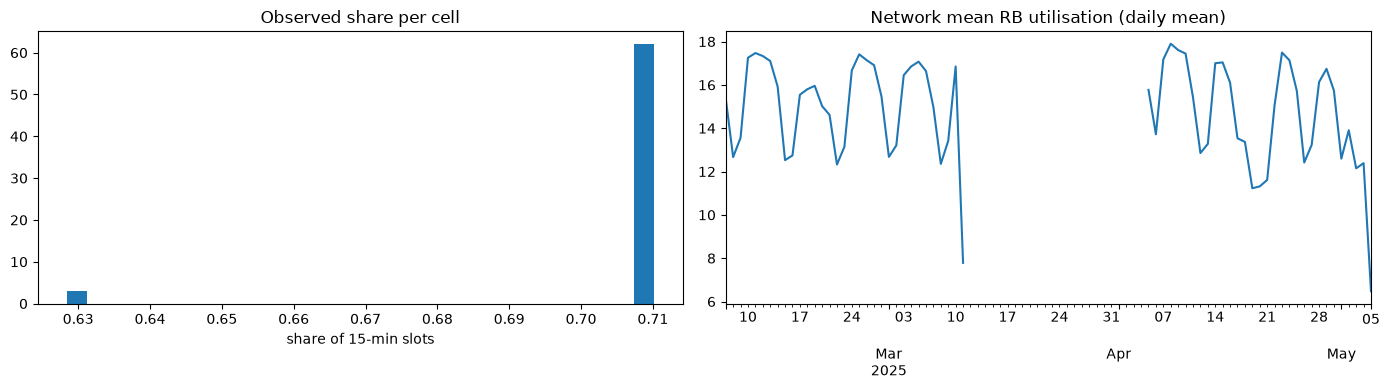

In [4]:
ix = panel.index
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
cov = panel.observed.mean(axis=1)
ax[0].hist(cov, bins=30); ax[0].set(title='Observed share per cell', xlabel='share of 15-min slots')
mean_rb = pd.DataFrame(rb.T, index=ix).mean(axis=1)
mean_rb.resample('D').mean().plot(ax=ax[1], title='Network mean RB utilisation (daily mean)')
plt.tight_layout(); plt.show()

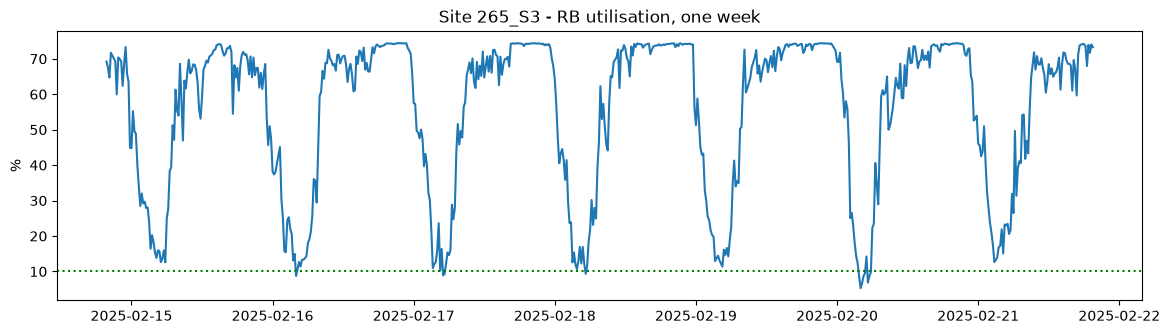

In [5]:
# Busiest cell, one week
cell = int(np.nanmean(rb, axis=1).argmax())
wk = slice(7 * 96, 14 * 96)
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(ix[wk], rb[cell, wk]); ax.axhline(10, color='g', ls=':')
ax.set(title=f'{panel.cells[cell]} - RB utilisation, one week', ylabel='%'); plt.show()

In [6]:
# Does radio-unit energy follow load? (decides how much a sleep decision can realistically save)
m = panel.observed & ~np.isnan(rb) & ~np.isnan(panel['energy_ru'])
bins = pd.cut(pd.Series(rb[m]), [-0.01, 0.5, 5, 10, 20, 40, 100])
print(pd.Series(panel['energy_ru'][m]).groupby(bins, observed=True).agg(['mean', 'count']))

                    mean   count
(-0.01, 0.5]   30.288122    1939
(0.5, 5.0]     33.689732   78439
(5.0, 10.0]    39.432327   78905
(10.0, 20.0]   43.409649  102069
(20.0, 40.0]   49.386353   71813
(40.0, 100.0]  59.244217   24173
